# Grids format

This example illustrates how to access to the atmospheric grid info to check the parameters and their ranges. The model ``Exo-REM`` will be considered here.

### Imports

In [35]:
import xarray as xr
import matplotlib.pyplot as plt

### Open the grid

You can check the free parameters names, ranges and units together with the wavelength range and spectral resolution.

In [36]:
grid_path = '/Users/spetrus/Desktop/models_grids/EXOREM_native.nc'
ds = xr.open_dataset(grid_path, decode_cf=False)
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:     (wavelength: 29922, par1: 33, par2: 5, par3: 4, par4: 15)
Coordinates:
  * wavelength  (wavelength) float64 239kB 0.6667 0.6667 0.6667 ... 248.4 251.6
  * par1        (par1) float64 264B 400.0 450.0 500.0 ... 1.9e+03 1.95e+03 2e+03
  * par2        (par2) float64 40B 3.0 3.5 4.0 4.5 5.0
  * par3        (par3) float64 32B -0.5 0.0 0.5 1.0
  * par4        (par4) float64 120B 0.1 0.15 0.2 0.25 0.3 ... 0.65 0.7 0.75 0.8
Data variables:
    grid        (wavelength, par1, par2, par3, par4) float64 2GB ...
Attributes:
    key:      ['par1', 'par2', 'par3', 'par4']
    par:      ['teff', 'logg', 'mh', 'co']
    title:    ['Teff', 'log(g)', '[M/H]', 'C/O']
    unit:     ['(K)', '(dex)', '', '']
    res:      [29999.50000004 29998.49999991 29997.50000002 ...    80.5\n    ...


The attributes provide valuable information about which parameter is explored by each dimension of the grid. You can get the array of each parameters with:

In [39]:
# Open the grid
grid = ds['grid']

# Get the parameter
Teff_tab = grid['par1'].values   # if par 1 correspond to the parameter Teff
print(Teff_tab)

[ 400.  450.  500.  550.  600.  650.  700.  750.  800.  850.  900.  950.
 1000. 1050. 1100. 1150. 1200. 1250. 1300. 1350. 1400. 1450. 1500. 1550.
 1600. 1650. 1700. 1750. 1800. 1850. 1900. 1950. 2000.]


The attributes also contain the spectral resolution of the synthetic spectra at each wavelength. To access it, please run:

In [40]:
# Open the grid
grid = ds['grid']

# Get the resolution
res = ds.attrs["res"]
print(res)

[29999.50000004 29998.49999991 29997.50000002 ...    80.5
    79.5           80.5       ]


### Get a spectrum for specific values

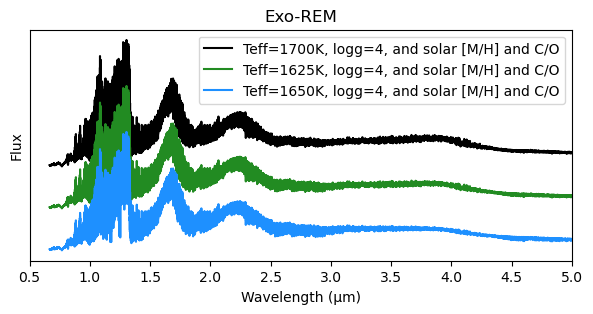

In [38]:
# Open the grid 
grid = ds['grid']

# Get wavelength 
wave = grid['wavelength'].values

# For Exo-REM par1=Teff, par2=logg, par3=[M/H], par4=C/O
# Get flux by selecting a value for each parameter
flux_sel = grid.sel(par1=1700,par2=4.0, par3=0., par4=0.55, method="nearest")
# Get flux by selecting an index for each parameter
flux_isel = grid.isel(par1=25,par2=2, par3=1, par4=9)
# Get flux by interpolating an index for each parameter
flux_interp = grid.interp(par1=1675,par2=4.0, par3=0., par4=0.55, method="linear")

# Plot the spectrum
plt.figure(figsize=(7,3))
plt.plot(wave, flux_sel*wave + 600000, 'k', label='Teff=1700K, logg=4, and solar [M/H] and C/O')
plt.plot(wave, flux_interp*wave + 300000, 'forestgreen', label='Teff=1625K, logg=4, and solar [M/H] and C/O')
plt.plot(wave, flux_isel*wave, 'dodgerblue', label='Teff=1650K, logg=4, and solar [M/H] and C/O')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux')
plt.xlim(0.5,5) 
plt.yticks([])
plt.title('Exo-REM')
plt.legend()
plt.show()

To know more about the grid format used in ForMoSA, please visite [xarray](https://xarray.dev/) 